In [283]:
import numpy as np
import pandas as pd

In [284]:
df = pd.read_csv("car data.csv")

In [285]:
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [286]:
df.shape

(301, 9)

In [287]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [288]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [289]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [290]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [291]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [292]:
duplicate = df.duplicated().sum()

In [293]:
duplicate

np.int64(2)

In [294]:
D_Remove = df.drop_duplicates(inplace = True)

In [295]:
D_Remove

In [296]:
df["Car_Age"] = 2026 - df["Year"]
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [297]:
df = df.drop(["Car_Name", "Year"], axis=1)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [298]:
import matplotlib.pyplot as plt
import seaborn as sns

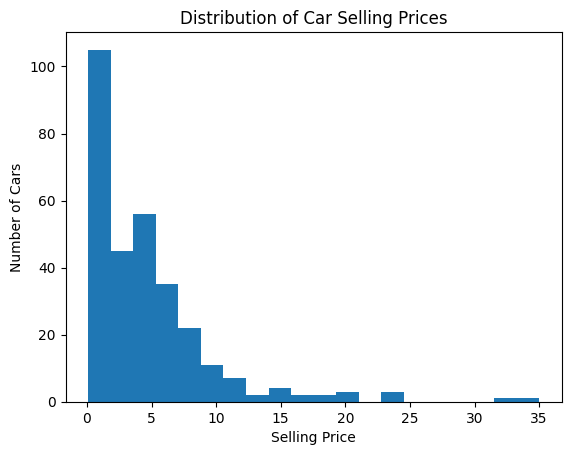

In [299]:
plt.hist(df["Selling_Price"], bins=20)

plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Selling Prices")

plt.show()

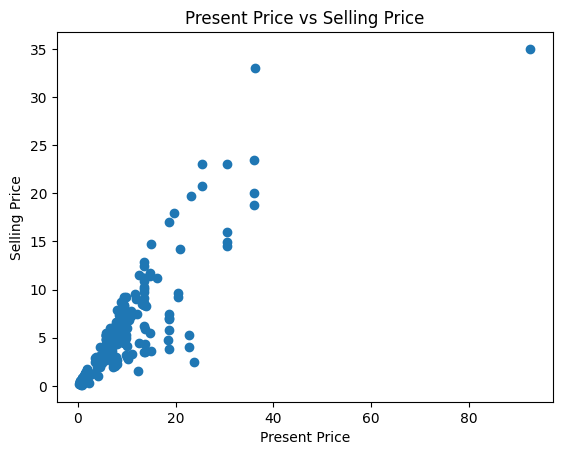

In [300]:
plt.scatter(df["Present_Price"], df["Selling_Price"])

plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Present Price vs Selling Price")

plt.show()

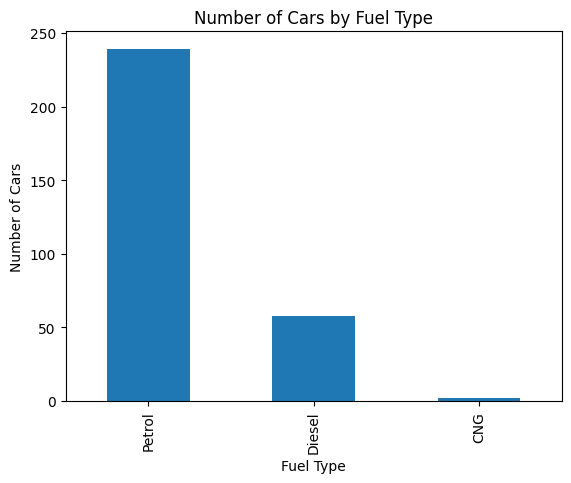

In [301]:
df["Fuel_Type"].value_counts().plot(kind="bar")

plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.title("Number of Cars by Fuel Type")

plt.show()

In [302]:
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [303]:
print(df.dtypes)

Selling_Price              float64
Present_Price              float64
Driven_kms                   int64
Owner                        int64
Car_Age                      int64
Fuel_Type_Diesel              bool
Fuel_Type_Petrol              bool
Selling_type_Individual       bool
Transmission_Manual           bool
dtype: object


In [304]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]


In [305]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [306]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [307]:
X_train.head()

,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
6,8.12,18796,0,11,False,True,False,True
185,0.58,1900,0,18,False,True,True,False
187,0.51,32000,0,13,False,True,True,True
148,0.94,45000,0,16,False,True,True,True
31,4.89,54200,0,15,False,True,False,True


In [308]:
y_train.head()

,Selling_Price
6,6.75
185,0.25
187,0.25
148,0.52
31,2.35


In [309]:
X_test.head()

,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
283,11.80,9010,0,10,False,True,False,True
267,9.40,19434,0,10,True,False,False,True
166,0.55,1000,0,10,False,True,True,True
9,8.92,42367,0,11,True,False,False,True
78,22.83,80000,0,16,False,True,False,False


In [310]:
y_test.head()

,Selling_Price
283,8.99
267,8.35
166,0.45
9,7.45
78,5.25


In [311]:
X_train.shape

(239, 8)

In [312]:
X_test.shape

(60, 8)

In [313]:
y_test.shape

(60,)

In [314]:
y_train.shape

(239,)

In [315]:
import sklearn as sk

In [316]:
from sklearn.ensemble import RandomForestRegressor

clf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

clf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [317]:
predictions = clf.predict(X_test)

predictions[:10]

array([ 9.5021,  8.28  ,  0.4424,  6.918 , 17.2575,  5.3155,  6.8465,
        1.1775,  7.866 ,  0.282 ])

In [318]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)


In [319]:
mae

1.4656383333333347

In [320]:
mse

12.317244055166675

In [321]:
rmse

np.float64(3.5095931466719437)

In [322]:
r2

0.5220921609005125

In [323]:
r2 = r2 * 100, "%"

In [324]:
r2

(52.20921609005125, '%')

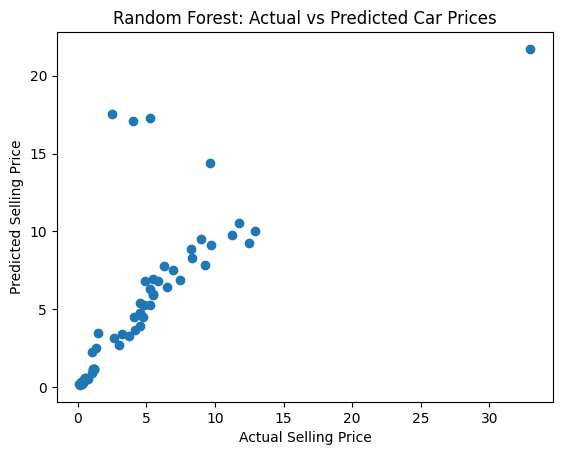

In [325]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Random Forest: Actual vs Predicted Car Prices")

plt.show()

In [326]:
import joblib
joblib.dump(model, "car_price_model.pkl")

['car_price_model.pkl']

In [327]:
from google.colab import files

files.download("car_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>